






















# **Project Name**    - Bike Rental



# Project ID - PRCP 1018

# Data Set Information:
Bike sharing systems are new generation of traditional bike rentals where whole process from membership, rental and return back has become automatic. Through these systems, user is able to easily rent a bike from a particular position and return back at another position. Currently, there are about over 500 bike-sharing programs around the world which is composed of over 500 thousands bicycles. Today, there exists great interest in these systems due to their important role in traffic, environmental and health issues.

Apart from interesting real world applications of bike sharing systems, the characteristics of data being generated by these systems make them attractive for the research. Opposed to other transport services such as bus or subway, the duration of travel, departure and arrival position is explicitly recorded in these systems. This feature turns bike sharing system into a virtual sensor network that can be used for sensing mobility in the city. Hence, it is expected that most of important events in the city could be detected via monitoring these data.


# Attribute Information:
Both hour.csv and day.csv have the following fields, except hr which is not available in day.csv

- instant: record index
- dteday : date
- season : season (1:winter, 2:spring, 3:summer, 4:fall)
- yr : year (0: 2011, 1:2012)
- mnth : month ( 1 to 12)
- hr : hour (0 to 23)
- holiday : weather day is holiday or not (extracted from [Web Link])
- weekday : day of the week
- workingday : if day is neither weekend nor holiday is 1, otherwise is 0.
+ weathersit :
- 1: Clear, Few clouds, Partly cloudy, Partly cloudy
- 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
- 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
- 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
- temp : Normalized temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-8, t_max=+39 (only in hourly scale)
- atemp: Normalized feeling temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-16, t_max=+50 (only in hourly scale)
- hum: Normalized humidity. The values are divided to 100 (max)
- windspeed: Normalized wind speed. The values are divided to 67 (max)
- casual: count of casual users
- registered: count of registered users
- cnt: count of total rental bikes including both casual and registered

# **Problem Statement**


Task 1:- Prepare a complete data analysis report on the given data.

Task 2:- Prediction of daily bike rental count based on the environmental and seasonal settings.

### Import Libraries

In [1]:
# Standard Libraries import for data handling and manipulation of dataset
import numpy as np
import pandas as pd
from numpy import math

#For handling date column
from datetime import datetime

#For visualization purpose
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as px
import plotly.express as x




#For feature selection
from sklearn import feature_selection
from statsmodels.stats.outliers_influence import variance_inflation_factor





%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [2]:
#reading data
day_df=pd.read_csv("day.csv")
hour_df=pd.read_csv("hour.csv")


### Dataset First View

In [3]:
# Dataset First Look
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [5]:
#Creating dictionary
data_dict={'Hour':hour_df,'Day':day_df}

### Dataset Rows & Columns count

In [6]:
# Dataset Rows & Columns count
for key,value in data_dict.items():
  print(f'{key} dataframe shape : {value.shape}')

Hour dataframe shape : (17379, 17)
Day dataframe shape : (731, 16)


### Dataset Information

In [7]:
# Dataset Info
for key,value in data_dict.items():
  print(f'--------{key} dataframe info--------\n')
  print(f'dataframe shape : {value.info()}\n')

--------Hour dataframe info--------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB
dataframe sh

#### Duplicate Values

In [8]:
# Dataset Duplicate Value Count
for key,value in data_dict.items():
  print(f'--------{key} dataframe duplicates--------\n')
  print(f'{value[value.duplicated()].count()}\n')


--------Hour dataframe duplicates--------

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

--------Day dataframe duplicates--------

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64



<b>There are no duplicate values in the dataset

#### Missing Values/Null Values

In [9]:
# Missing Values/Null Values Count
for key,value in data_dict.items():
  print(f'--------{key} dataframe Missing/Null Value--------\n')
  print(f'{value[value.isna()].count()}\n')



--------Hour dataframe Missing/Null Value--------

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

--------Day dataframe Missing/Null Value--------

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64



<b>No missing values in the dataset.

### What did you know about your dataset?

**Day Dataset**
1. Dataset contains 731 rows & 16 columns.

 2.All the columns have numerical variable.

 3.`holiday`, `weekday`,`workingday`, `weathersit` contains categorical values.

 4.`cnt` column is our target variable


**Hour Dataset**

1. Dataset contains 17379 rows & 17 columns.

 2.All the columns have numerical variable

 3.`holiday`, `weekday`,`workingday`, `weathersit` contains categorical values.

 4.`cnt` column is our target variable


* Dataset has no Null/Duplicate values and missing values in the dataset.


## ***2. Understanding Your Variables***

In [10]:
# Dataset Columns
for key,value in data_dict.items():
  print(f'--------{key} dataframe columns--------\n')
  print(f'{value.columns}\n')

--------Hour dataframe columns--------

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

--------Day dataframe columns--------

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')



In [11]:
# Dataset Describe
hour_df.describe(include='all')

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2011-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,NaN,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,NaN,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,NaN,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,NaN,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,NaN,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000


### Variables Description


* **datetime** - hourly date + timestamp
* **season** -  1 = spring, 2 = summer, 3 = fall, 4 = winter
* **holiday** - whether the day is considered a holiday
* **workingday** - whether the day is neither a weekend nor holiday
* **weather** -
      `1: Clear, Few clouds, Partly cloudy, Partly cloudy.
       2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
       3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
       4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
* **temp** - temperature in Celsius
* **atemp** - "feels like" temperature in Celsius
* **humidity** - relative humidity
* **windspeed** - wind speed
* **casual** - number of non-registered user rentals initiated
* **registered** - number of registered user rentals initiated
* **count** - number of total rentals

### Check Unique Values for each variable.

In [12]:
# Check Unique Values for each variable.
# and printing those columns which have less than 25 values
for i in hour_df.columns:
  print(f"Unique {i}'s count:{hour_df[i].nunique()}")
  if i in hour_df.columns:
    if(hour_df[i].nunique() < 25):
      print(f"{hour_df[i].unique()}\n")

Unique instant's count:17379
Unique dteday's count:731
Unique season's count:4
[1 2 3 4]

Unique yr's count:2
[0 1]

Unique mnth's count:12
[ 1  2  3  4  5  6  7  8  9 10 11 12]

Unique hr's count:24
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]

Unique holiday's count:2
[0 1]

Unique weekday's count:7
[6 0 1 2 3 4 5]

Unique workingday's count:2
[0 1]

Unique weathersit's count:4
[1 2 3 4]

Unique temp's count:50
Unique atemp's count:65
Unique hum's count:89
Unique windspeed's count:30
Unique casual's count:322
Unique registered's count:776
Unique cnt's count:869


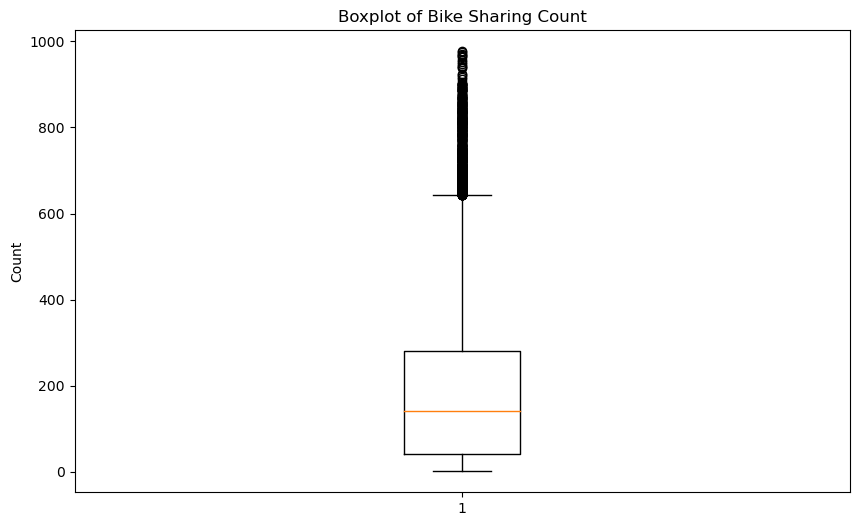

Outliers:
       instant      dteday  season  yr  mnth  hr  holiday  weekday  \
10383    10384  2012-03-13       1   1     3  18        0        2   
10406    10407  2012-03-14       1   1     3  17        0        3   
10407    10408  2012-03-14       1   1     3  18        0        3   
10431    10432  2012-03-15       1   1     3  18        0        4   
10527    10528  2012-03-19       1   1     3  18        0        1   
...        ...         ...     ...  ..   ...  ..      ...      ...   
15828    15829  2012-10-26       4   1    10  17        0        5   
15848    15849  2012-10-27       4   1    10  13        0        6   
15849    15850  2012-10-27       4   1    10  14        0        6   
16726    16727  2012-12-04       4   1    12  17        0        2   
16741    16742  2012-12-05       4   1    12   8        0        3   

       workingday  weathersit  temp   atemp   hum  windspeed  casual  \
10383           1           1  0.70  0.6364  0.34     0.2985      96   
10406

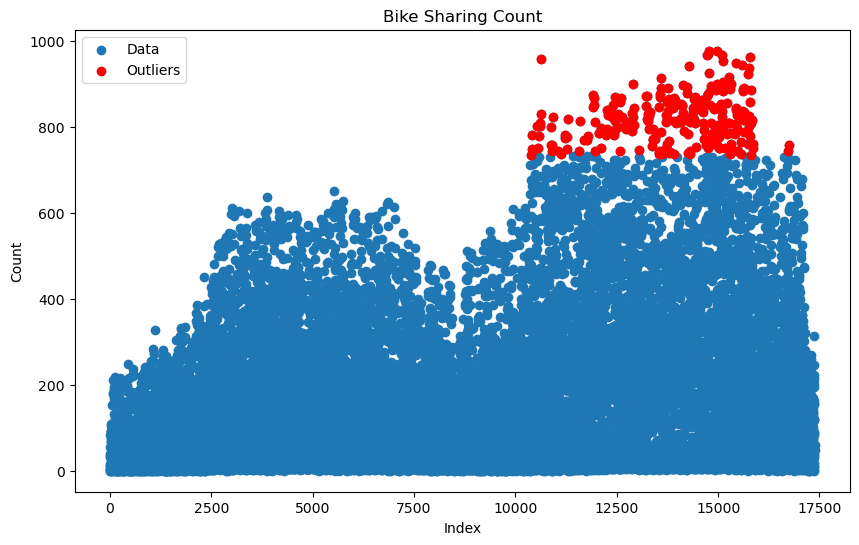

In [13]:

import matplotlib.pyplot as plt

# Check for outliers in the "count" variable
plt.figure(figsize=(10, 6))
plt.boxplot(hour_df['cnt'])
plt.title('Boxplot of Bike Sharing Count')
plt.ylabel('Count')
plt.show()

# Calculate the z-scores for each data point in the "count" variable
z_scores = (hour_df['cnt'] - hour_df['cnt'].mean()) / hour_df['cnt'].std()

# Identify outliers based on a threshold (e.g., z-score > 3)
outliers = hour_df[z_scores > 3]

# Print the outliers
print("Outliers:")
print(outliers)

# Visualize the outliers
plt.figure(figsize=(10, 6))
plt.scatter(hour_df.index, hour_df['cnt'], label='Data')
plt.scatter(outliers.index, outliers['cnt'], color='red', label='Outliers')
plt.title('Bike Sharing Count')
plt.xlabel('Index')
plt.ylabel('Count')
plt.legend()
plt.show()


#<b>Handling outliers

In this dataset, our objective is to predict optimum bike-sharing demand during each hour to maintain a stable supply of bikes to the customers. So I have decided to keep these outliers for correctly predicting bike sharing demand during these exceptional circumstances. Else I would have used an interquartile range to filter the outliers.

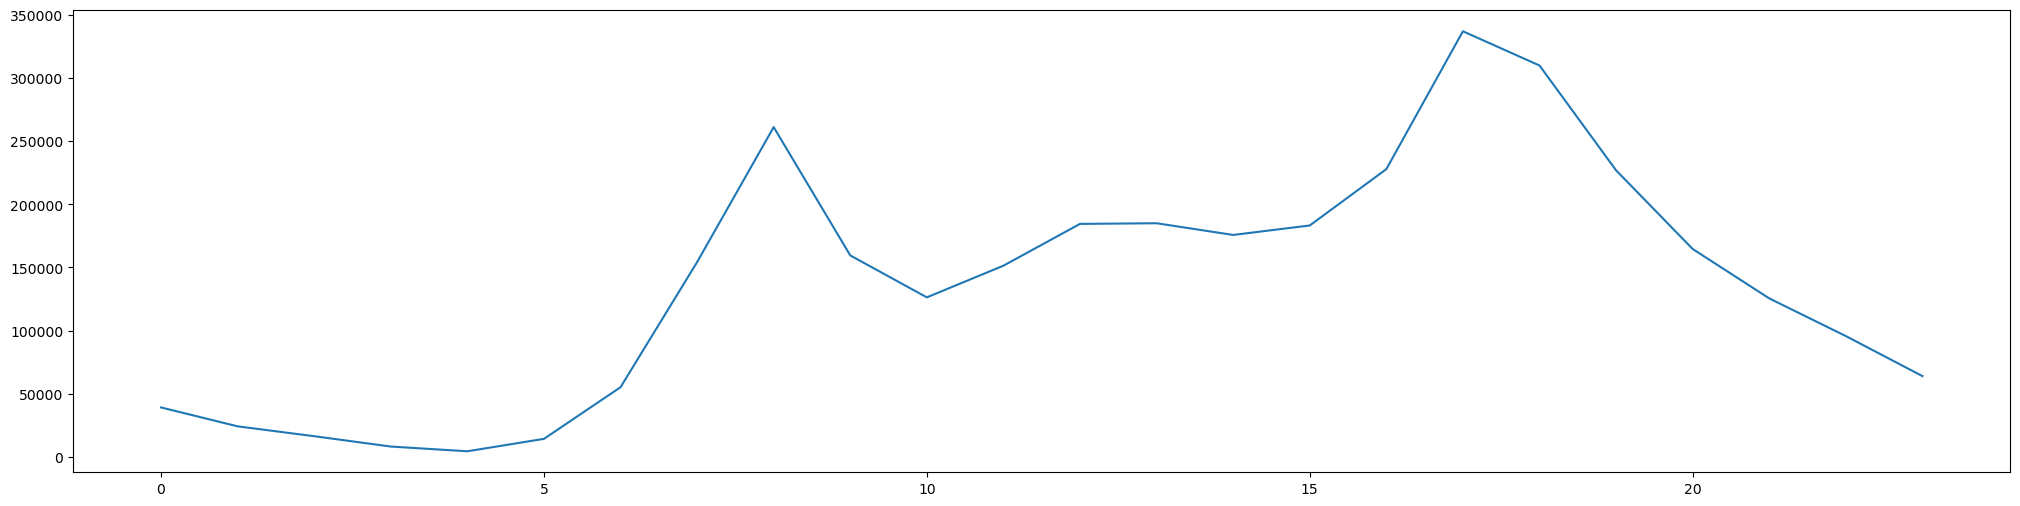

In [14]:
#lineplot of datewise bike sharing demand
count_date=hour_df.groupby(['hr'])['cnt'].sum().reset_index()
fig = plt.figure(figsize=(25,6))
ax = plt.axes()
x = count_date['hr']
ax.plot(x, count_date['cnt'])
plt.show()

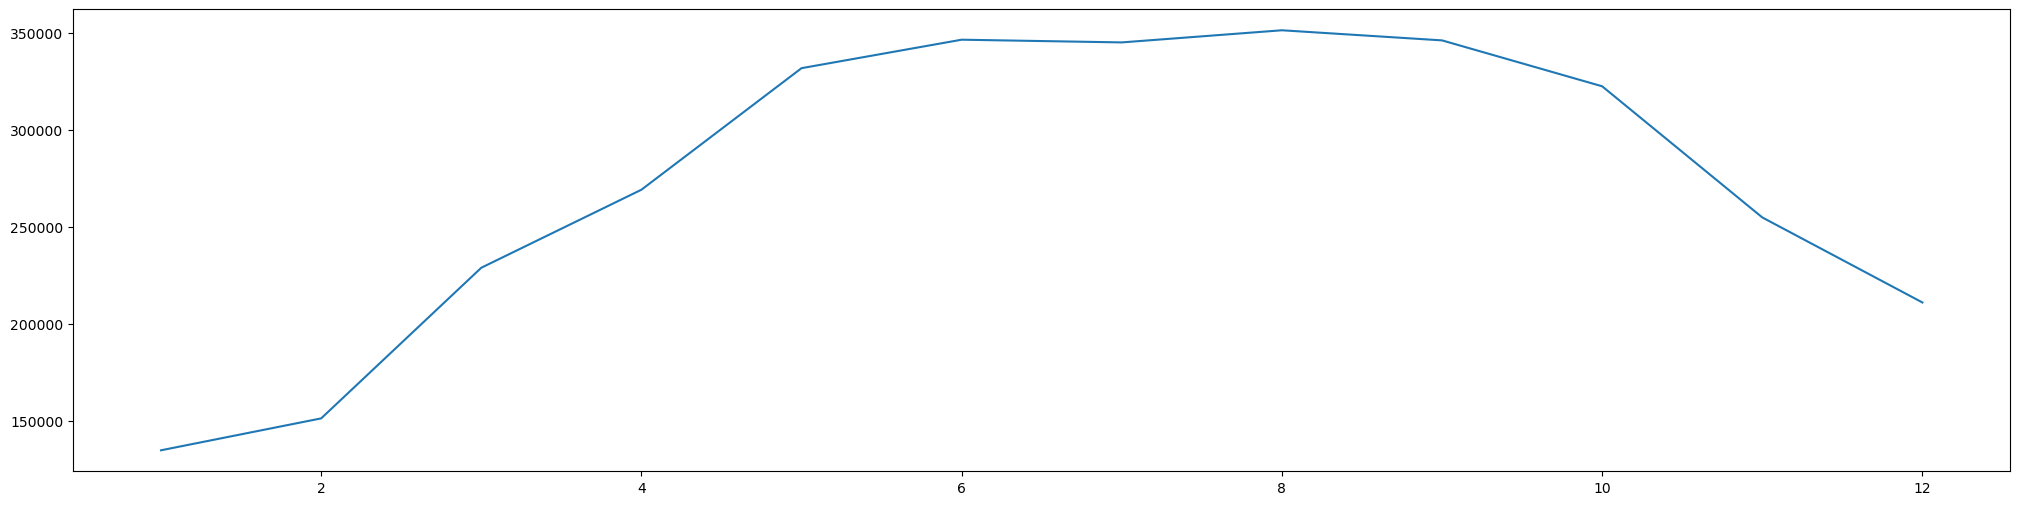

In [15]:
# Lineplot of monthly bike sharing demand
count_date=hour_df.groupby(['mnth'])['cnt'].sum().reset_index()
fig = plt.figure(figsize=(25,6))
ax = plt.axes()
x = count_date['mnth']
ax.plot(x, count_date['cnt'])
plt.show()

## 3. ***Data Wrangling***

### Data Wrangling Code

In [16]:
hour_df.rename(columns={'instant':'rec_id','dteday':'datetime','holiday':'is_holiday','workingday':'is_workingday',
                        'weathersit':'weather_condition','hum':'humidity','mnth':'month',
                        'cnt':'total_count','hr':'hour','yr':'year'},inplace=True)
hour_df.head()

,rec_id,datetime,season,year,month,hour,is_holiday,weekday,is_workingday,weather_condition,temp,atemp,humidity,windspeed,casual,registered,total_count
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


Type casting the datetime and categorical attributes

In [17]:
hour_df['datetime']=pd.to_datetime(hour_df.datetime)

hour_df['season']=hour_df.season.astype('category')
hour_df['year']=hour_df.year.astype('category')
hour_df['month']=hour_df.month.astype('category')
hour_df['hour']=hour_df.hour.astype('category')
hour_df['is_holiday']=hour_df.is_holiday.astype('category')
hour_df['weekday']=hour_df.weekday.astype('category')
hour_df['is_workingday']=hour_df.is_workingday.astype('category')
hour_df['weather_condition']=hour_df.weather_condition.astype('category')

In [18]:
hour_df.head()

,rec_id,datetime,season,year,month,hour,is_holiday,weekday,is_workingday,weather_condition,temp,atemp,humidity,windspeed,casual,registered,total_count
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#<b> Time Frame

###<b>Seasonwise Hourly distribution of bikes

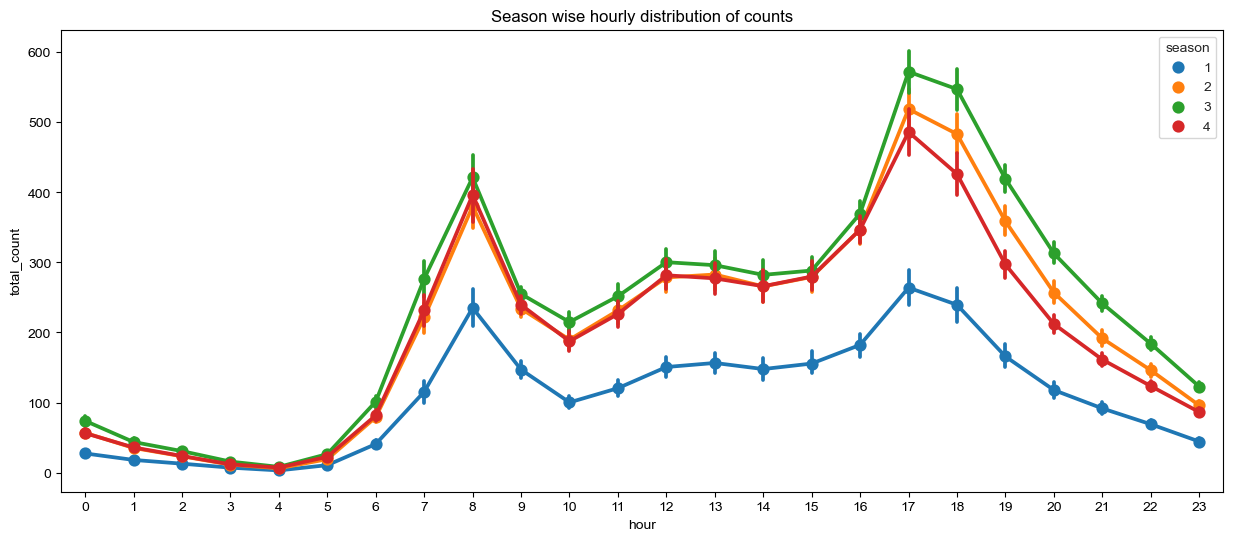

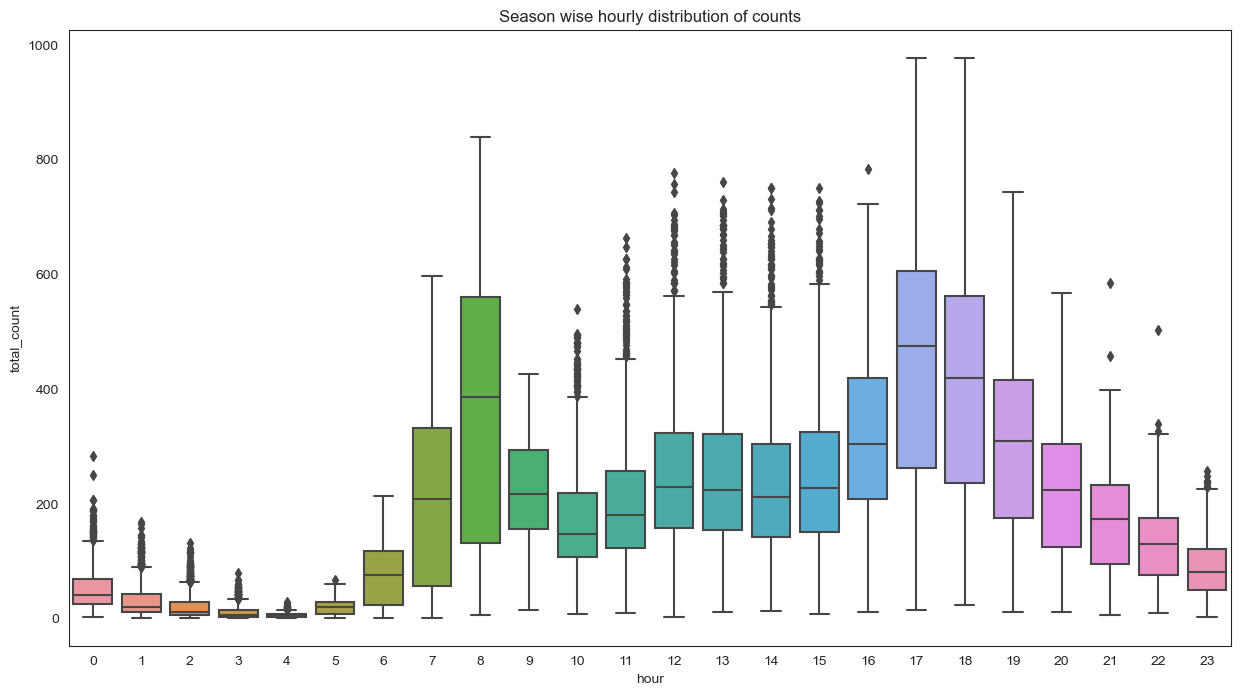

In [19]:
fig,ax=plt.subplots(figsize=(15,6))
sns.set_style('white')

sns.pointplot(x='hour',y='total_count',data=hour_df[['hour','total_count','season']],hue='season',ax=ax)
ax.set_title('Season wise hourly distribution of counts')
plt.show()
fig,ax1=plt.subplots(figsize=(15,8))
sns.boxplot(x='hour',y='total_count',data=hour_df[['hour','total_count']],ax=ax1)
ax1.set_title('Season wise hourly distribution of counts')
plt.show()

###<b>Weekdaywise hourly distribution of count.

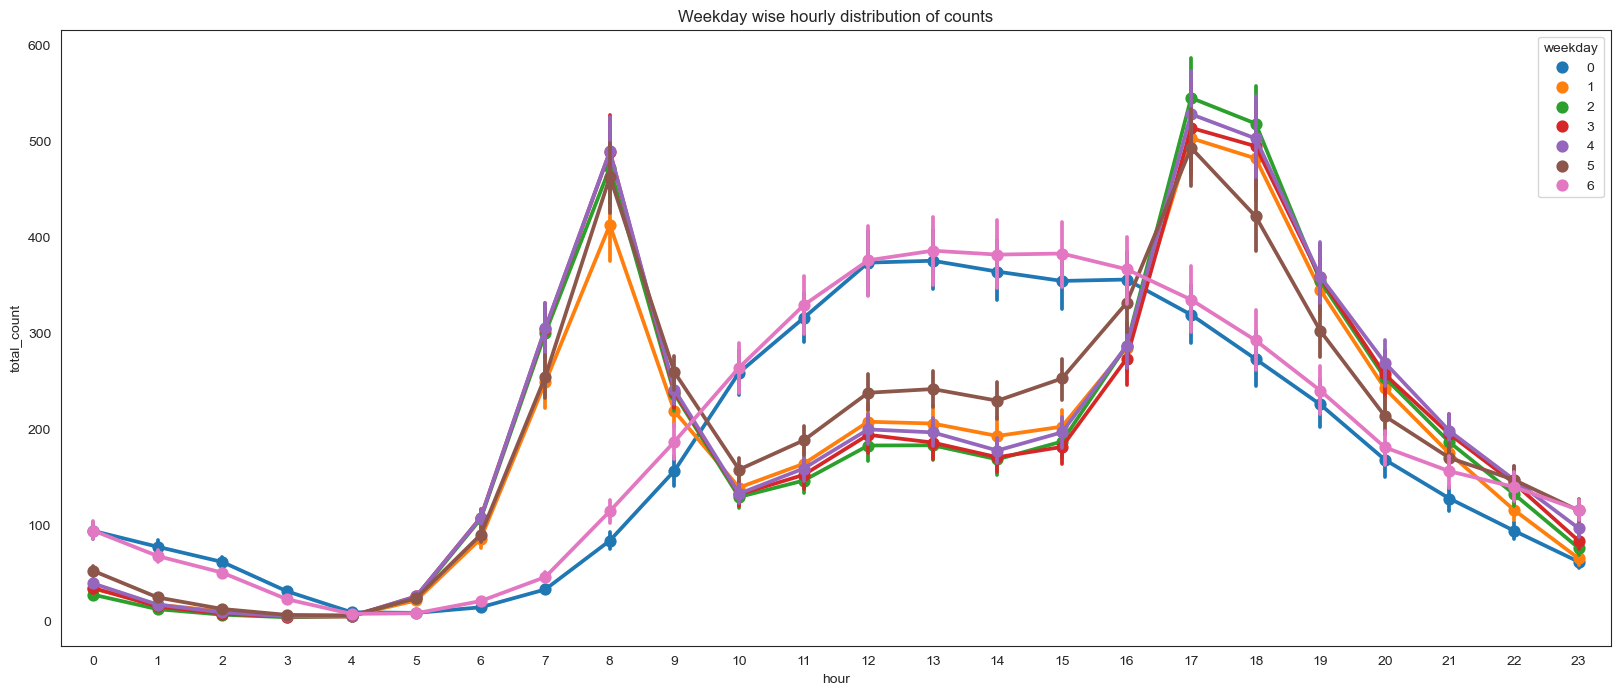

In [20]:
fig,ax=plt.subplots(figsize=(20,8))
sns.pointplot(x='hour',y='total_count',data=hour_df[['hour','total_count','weekday']],hue='weekday')
ax.set_title('Weekday wise hourly distribution of counts')
plt.show()

###<b> Monthly distribution of counts.

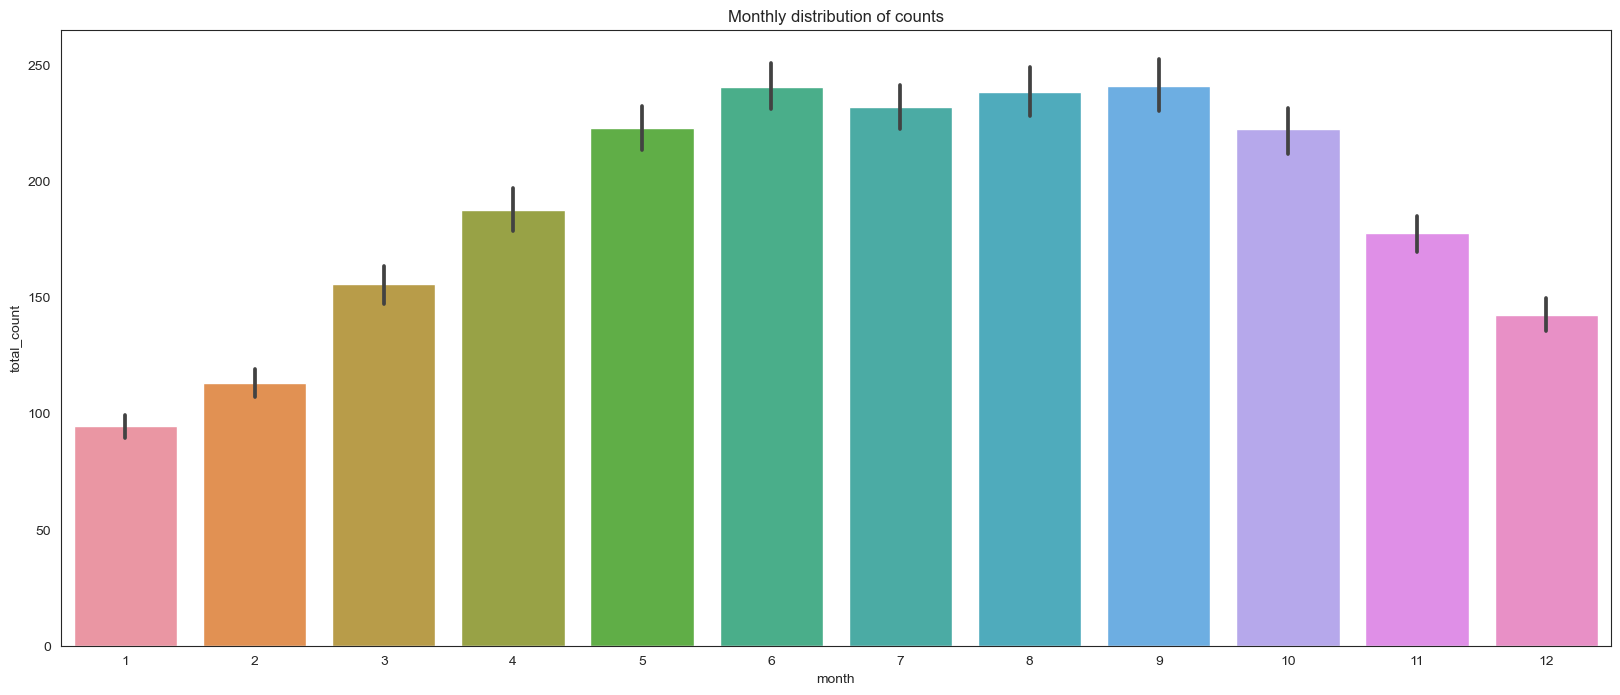

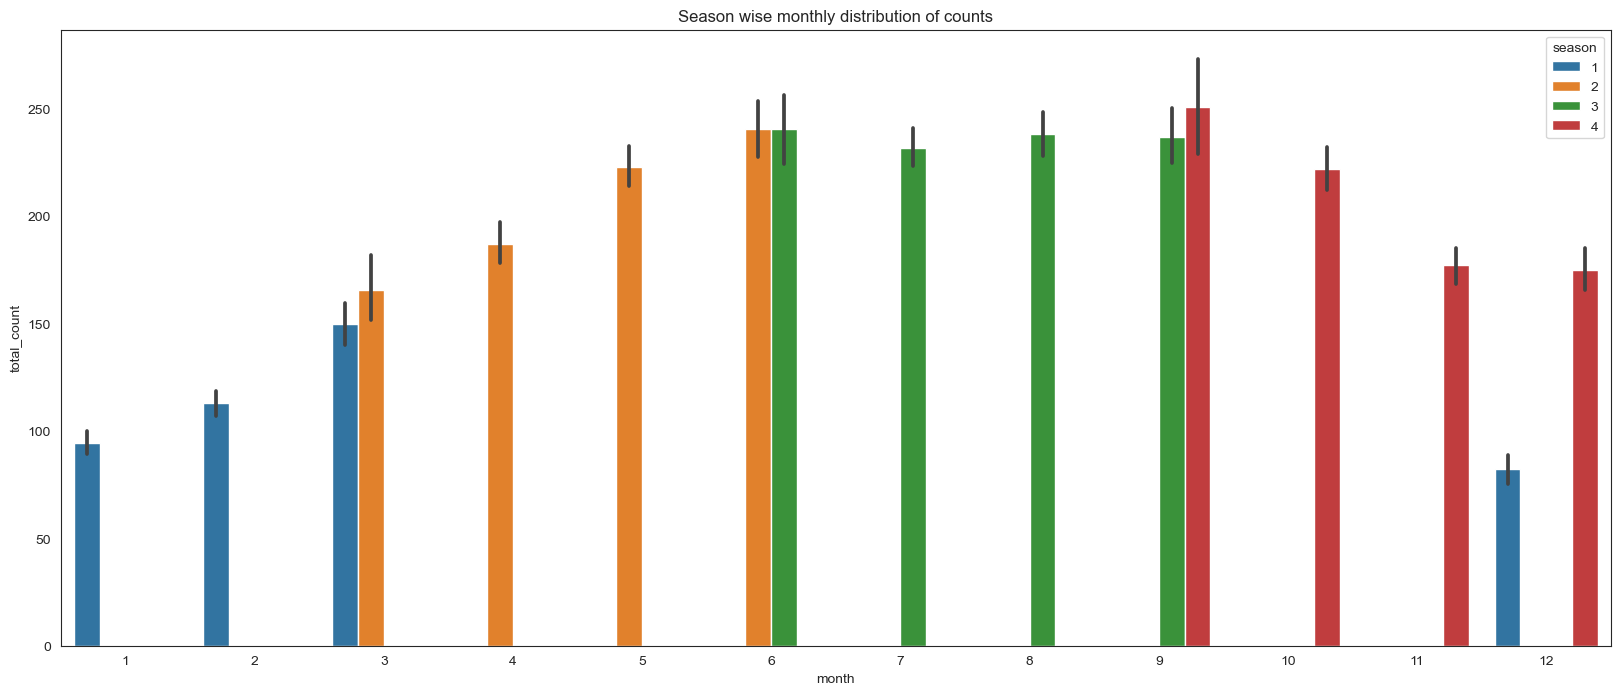

In [21]:
fig,ax1=plt.subplots(figsize=(20,8))
sns.barplot(x='month',y='total_count',data=hour_df[['month','total_count']],ax=ax1)
ax1.set_title('Monthly distribution of counts')
plt.show()
fig,ax2=plt.subplots(figsize=(20,8))
sns.barplot(x='month',y='total_count',data=hour_df[['month','total_count','season']],hue='season',ax=ax2)
ax2.set_title('Season wise monthly distribution of counts')
plt.show()

###<b> Yearwise Distribution of counts.

###<b> Heatmap

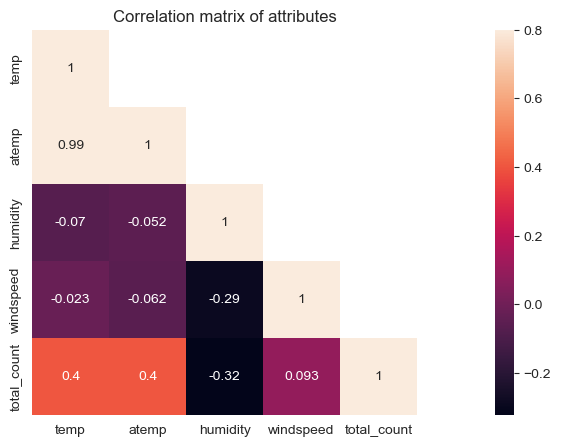

In [22]:
correMtr=hour_df[["temp","atemp","humidity","windspeed","total_count"]].corr()
mask=np.array(correMtr)
mask[np.tril_indices_from(mask)]=False
fig,ax=plt.subplots(figsize=(20,5))
sns.heatmap(correMtr,mask=mask,vmax=0.8,square=True,annot=True,ax=ax)
ax.set_title('Correlation matrix of attributes')
plt.show()

#<b>Impact of Holidays

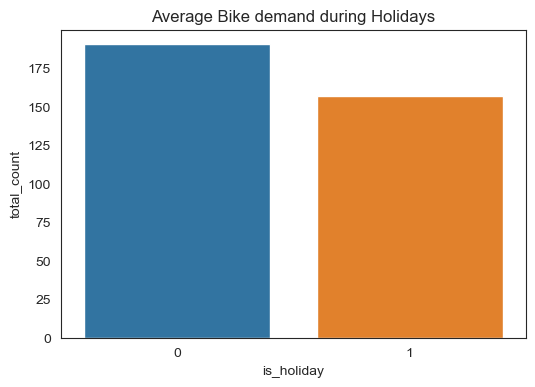

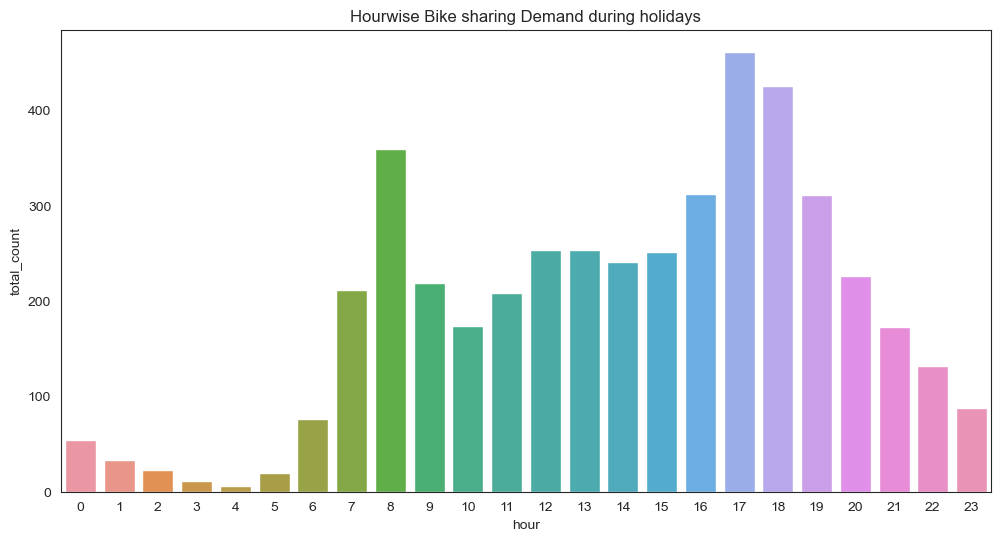

In [23]:
# Chart - 9 visualization code
import plotly.express as x
#Barplot of holiday vs rented bike count
y=hour_df.groupby('is_holiday')['total_count'].mean().reset_index()
fig = plt.subplots(figsize=(6, 4))
sns.barplot(x ='is_holiday',
            y ='total_count',
            data = y).set_title('Average Bike demand during Holidays')
plt.show()

#For plotting hourwise demand during holidays
c=hour_df.groupby('hour')['total_count'].mean().reset_index()

fig = plt.subplots(figsize=(12, 6))
sns.barplot(x ='hour',
            y ='total_count',
            data = c).set_title('Hourwise Bike sharing Demand during holidays')
plt.show()

#Pie plot showing percentage of demand per hour during holidays
fig = x.pie(c, values='total_count', names=c['hour'].unique(),title='Percentage of Hourwise Bike sharing Demand during holidays')
fig.update_layout(autosize=False,width=600,height=400,legend_title_text = "Hour of the day")
fig.update_layout(autosize=True,width=750,height=600)


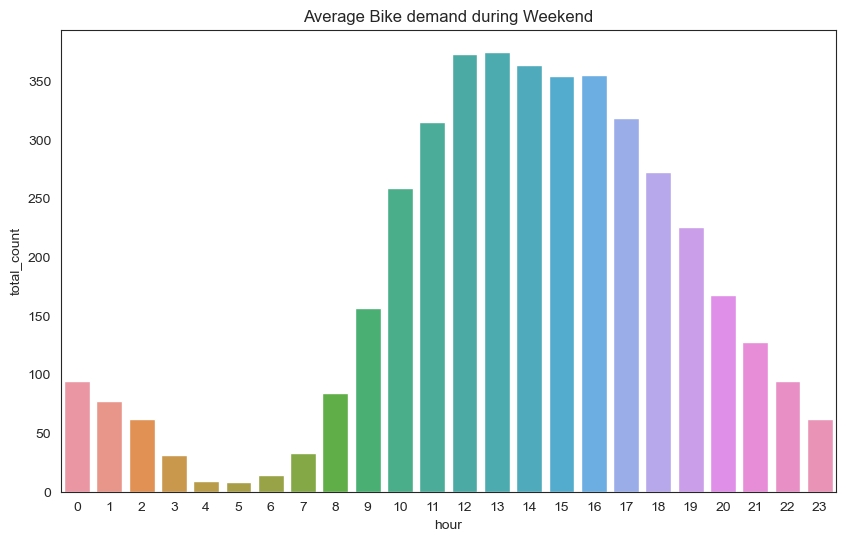

In [24]:

y=hour_df.groupby(['weekday','hour'])['total_count'].mean().reset_index()

#Bar plot to show hourwise demand during weekend
y=y[y['weekday']==0]
fig = plt.subplots(figsize=(10, 6))
sns.barplot(x ='hour',
            y ='total_count',
            data = y).set_title('Average Bike demand during Weekend')
plt.show()

#Pie plot showing percentage of demand per hour during weekend
fig = x.pie(y, values='total_count', names=y['hour'].unique(),title='Percentage of average hourwise Bike demand during Weekend')
fig.update_layout(autosize=False,width=600,height=400,legend_title_text = "Hour of the day")
fig.update_layout(autosize=True,width=750,height=600)

# Model Training

In [25]:
df =hour_df
df.head()

,rec_id,datetime,season,year,month,hour,is_holiday,weekday,is_workingday,weather_condition,temp,atemp,humidity,windspeed,casual,registered,total_count
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [26]:
#dropping id column as it is irrelevant to our analysis
df=df.drop(labels=['rec_id','datetime','casual','registered'],axis=1)

In [27]:
## Seprating Independent and dependent features
X = df.drop(labels=['total_count'],axis=1)
Y = df[['total_count']]

In [28]:
#checking target variable
Y

,total_count
0,16
1,40
2,32
3,13
4,1
...,...
17374,119
17375,89
17376,90
17377,61


In [29]:
# Defining which columns should be ordinal-encoded and which should be scaled
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(exclude='object').columns

In [30]:
numerical_cols

Index(['season', 'year', 'month', 'hour', 'is_holiday', 'weekday',
       'is_workingday', 'weather_condition', 'temp', 'atemp', 'humidity',
       'windspeed'],
      dtype='object')

# Feature Engineering

In [31]:
# for handling Missing Values
from sklearn.impute import SimpleImputer 

# for Feature Scaling
from sklearn.preprocessing import StandardScaler 

# for Ordinal Encoding
from sklearn.preprocessing import OrdinalEncoder 

## for creating pipelines
from sklearn.pipeline import Pipeline

#for combining pipelines
from sklearn.compose import ColumnTransformer

In [32]:
# Numerical Pipeline
num_pipeline=Pipeline(
    steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())

    ]

)

# Categorigal Pipeline
cat_pipeline=Pipeline(
    steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('ordinalencoder',OrdinalEncoder(categories=[])),
    ('scaler',StandardScaler())
    ]

)

preprocessor=ColumnTransformer([
('num_pipeline',num_pipeline,numerical_cols),
('cat_pipeline',cat_pipeline,categorical_cols)
])

# Feature Slection

In [33]:
## Train test split
from sklearn import preprocessing

# Example usage of a preprocessing module
scaler = preprocessing.StandardScaler()

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.30,random_state=30)

In [34]:
#scaling dataset
X_train=pd.DataFrame(preprocessor.fit_transform(X_train),columns=preprocessor.get_feature_names_out())
X_test=pd.DataFrame(preprocessor.transform(X_test),columns=preprocessor.get_feature_names_out())

In [35]:
#checking for scaling
X_train.head()

,num_pipeline__season,num_pipeline__year,num_pipeline__month,num_pipeline__hour,num_pipeline__is_holiday,num_pipeline__weekday,num_pipeline__is_workingday,num_pipeline__weather_condition,num_pipeline__temp,num_pipeline__atemp,num_pipeline__humidity,num_pipeline__windspeed
0,-0.454097,-0.998932,-0.444446,-0.804873,-0.17262,0.995400,0.679808,-0.663381,-0.192936,-0.125990,1.319069,-0.699798
1,1.351162,-0.998932,1.007950,-0.804873,5.79307,-1.001062,-1.471003,-0.663381,-0.296368,-0.213548,1.630755,-1.550843
2,-1.356727,-0.998932,-1.606364,1.500483,-0.17262,1.494516,-1.471003,0.903007,-0.503231,-0.389244,1.630755,0.272591
3,-1.356727,-0.998932,-1.025405,0.780059,-0.17262,0.995400,0.679808,-0.663381,-0.813525,-0.916330,-0.706890,0.272591
4,0.448532,1.001069,0.717471,-0.228534,-0.17262,0.995400,0.679808,-0.663381,1.151674,1.280153,0.591802,-0.457108


In [36]:
!pip install lightgbm

In [37]:
## Model Training

from sklearn.linear_model import LinearRegression,Lasso,Ridge,ElasticNet
import xgboost as xgb
from lightgbm import LGBMRegressor
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import RandomForestRegressor,ExtraTreesRegressor

#for metric evaluation
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [38]:
#function to evaluate model using mae,rmse and R2 score  
import numpy as np
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [39]:
## Training  multiple models

models={
    'LinearRegression':LinearRegression(),
    'Random Forest':RandomForestRegressor(),
    'Extra Trees Regressor':ExtraTreesRegressor(),
    'Lightgbm':LGBMRegressor(),
    'XGboost':xgb.XGBRegressor()
}
trained_model_list=[]
model_list=[]
r2_list=[]

for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train)

    #Make Predictions
    y_pred=model.predict(X_test)

    mae, rmse, r2_square=evaluate_model(y_test,y_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model Training Performance')
    print("RMSE:",rmse)
    print("MAE:",mae)
    print("R2 score",r2_square*100)

    r2_list.append(r2_square)
    
    print('='*35)
    print('\n')

LinearRegression
Model Training Performance
RMSE: 141.8271103556539
MAE: 105.74549274614643
R2 score 38.45593358957478


Random Forest
Model Training Performance
RMSE: 44.98949547833301
MAE: 26.73189397135916
R2 score 93.80715906835387


Extra Trees Regressor
Model Training Performance
RMSE: 42.84340094697995
MAE: 25.88166954353663
R2 score 94.38389064681287


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001953 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 288
[LightGBM] [Info] Number of data points in the train set: 12165, number of used features: 12
[LightGBM] [Info] Start training from score 189.916975
Lightgbm
Model Training Performance
RMSE: 42.83793831431912
MAE: 26.800450116722306
R2 score 94.38532268936302


XGboost
Model Training Performance
RMSE: 42.948759765282375
MAE: 26.96642420281012
R2 score 94.35623484999238




# Final model for predicting the bike rental count on daily basis

When we compare the root mean squared error and mean absolute error of all 3 models, the random forest model has less root mean squared error and mean absolute error. So, finally random forest model is bset for predicting the bike rental count on daily basis.


In [40]:
y_test=y_test.total_count.values

In [41]:
Bike_df1=pd.DataFrame(y_test,columns=['y_test'])
Bike_df2=pd.DataFrame(y_pred,columns=['y_pred'])
Bike_predictions=pd.merge(Bike_df1,Bike_df2,left_index=True,right_index=True)
Bike_predictions.to_csv('Bike_Renting_Python.csv')
Bike_predictions

,y_test,y_pred
0,208,202.689423
1,2,-5.853703
2,440,368.982635
3,213,216.777191
4,158,160.731247
...,...,...
5209,62,180.475876
5210,5,3.242346
5211,576,636.722595
5212,290,324.008179


# Conclusion

The analysis aimed to predict the number of rented bikes based on weather and time-related features. The analysis began with a thorough exploration of the dataset, examining its distribution, and establishing relationships between variables. Key features include temperature, humidity, wind speed, hours of the day, seasons, holidays, and functioning days. It was observed that while certain variables exhibited linear relationships, others did not conform to such patterns. Among the models evaluated, the performance metrics indicate that the LightGBM model stands out as the most effective for predictive analysis.

With an R-squared value of 94.38, it explains a good model. The model also exhibits the lowest Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and Mean Absolute Error (MAE), indicating superior accuracy in predicting the target variable compared to other models. 